# Masterclass: Introduction to LangGraph & Agentic Workflows

Welcome to the comprehensive guide on **LangGraph**, LangChain's low-level framework for building stateful, multi-actor agentic applications. Unlike standard linear chains or pre-packaged ReAct agents, LangGraph provides granular control over **state persistence, loops, conditional routing, human-in-the-loop validation, and self-correction mechanics**.

### Notebook Overview & Learning Roadmap

| Section | Focus Area | Key Concepts Introduced |
|---|---|---|
| **1. Core Fundamentals** | Basic Graph Execution | `TypedDict` State, Nodes, Edges, `START`/`END`, `StateGraph.compile()` |
| **2. Chatbot Integration** | Chat Memory Management | `MessagesState`, `add_messages` reducer, `ChatGroq` integration |
| **3. Metadata Tracking** | Custom State Pipelines | `NotRequired` fields, decoupling LLM generation from `usage_metadata` extraction |
| **4. Enterprise Agentic RAG** | Autonomous Routing & Self-Correction | Supervisor Router, Structured Pydantic Output, RAG / Web / LLM Nodes, Quality Control Validator, Retry Loop |

## 1. LangGraph Core Fundamentals

LangGraph operates as a **finite state machine (FSM)**. Every application begins by defining a **State schema**, creating **Nodes** (Python functions that transform state), and connecting nodes via **Edges** (directional execution flow).

In [1]:
# Example helper node function demonstrating input/output dict pattern
def hello_node(input: str):
    return {"message": f"Hello, {input}!"}

In [2]:
# Test execution of basic node function
hello_node("areeb")

{'message': 'Hello, areeb!'}

### 1.1 Defining State Schema with TypedDict
In LangGraph, the `State` is a central data structure passed to every node. Nodes receive the current state as input and return a dictionary of state updates.

In [3]:
# Import TypedDict from typing_extensions
from typing_extensions import TypedDict

In [4]:
# Define State schema using TypedDict
class State(TypedDict):
    message: str

In [5]:
# Create a sample State object instance
state: State = {"message": "hello areeb"}
state

{'message': 'hello areeb'}

### 1.2 Defining Graph Nodes
A node is a standard Python function that takes `state` as input and returns a dictionary with key updates to be merged into the graph state.

In [6]:
# Refactor node function to accept State object
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

### 1.3 Building, Connecting, and Compiling the Graph
We instantiate `StateGraph(State)`, add our node, define execution edges (`START -> node -> END`), and compile the graph into an executable application.

In [7]:
# Import StateGraph, START, and END from langgraph.graph
from langgraph.graph import StateGraph, START, END

In [12]:
# Instantiate StateGraph with State schema
builder = StateGraph(State)

In [13]:
# Add node to graph builder
builder.add_node("first_hello_node", hello_node)

In [14]:
# Define edge from START entry point to first_hello_node
builder.add_edge(START, "first_hello_node")

In [15]:
# Define edge from first_hello_node to END terminal point
builder.add_edge("first_hello_node", END)

In [16]:
# Compile graph builder into an executable app
graph = builder.compile()

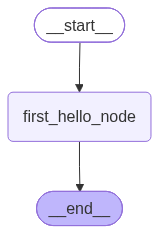

In [18]:
# Render and display graph mermaid visual workflow
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### 1.4 Invoking the Compiled Graph
We execute the graph by calling `graph.invoke(initial_state)`. LangGraph routes the state through the graph edges and returns the final updated state.

In [20]:
# Invoke graph with initial input state
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [21]:
# Store graph invocation output state in variable
result = graph.invoke({"message": "from INDIA"})

In [22]:
# Access specific message key from returned state
result["message"]

'Hello, from INDIA!'

### 1.5 Multi-Node Sequential Pipeline & State Mutation
Demonstrating how state flows sequentially across multiple nodes (`func1` -> `func2`), where each node reads previous outputs and appends new data.

In [60]:
# Define custom State schema for multi-node pipeline
class Areeb(TypedDict):
    text: str

In [61]:
# First node function modifying text state
def function1(state: Areeb):
    print(f"state from first function : {state}")
    return {"text": state["text"] + " from first function"}

In [70]:
# Second node function appending text to state
def function2(state: Areeb):
    print(f"state from second function : {state}")
    return {"text": state["text"] + " areeb from second function"}

In [71]:
# Instantiate multi-node StateGraph
workflow = StateGraph(Areeb)

In [72]:
# Register func1 and func2 nodes
workflow.add_node("func1", function1)
workflow.add_node("func2", function2)

In [73]:
# Define sequential edges: START -> func1 -> func2 -> END
workflow.add_edge(START, "func1")
workflow.add_edge("func1", "func2")
workflow.add_edge("func2", END)

In [74]:
# Compile multi-node workflow graph
app = workflow.compile()

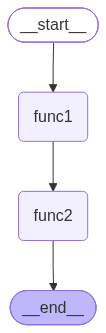

In [75]:
# Render mermaid diagram for multi-node pipeline
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [76]:
# Invoke multi-node workflow with initial state
result = app.invoke({"text": "hi, this is Areeb"})

state from first function : {'text': 'hi, this is Areeb'}
state from second function : {'text': 'hi, this is Areeb from first function'}


In [77]:
# Inspect complete state object after execution
result

{'text': 'hi, this is Areeb from first function areeb from second function'}

In [78]:
# Extract final text value from output state
result["text"]

'hi, this is Areeb from first function areeb from second function'

#### Sequential State Evolution Breakdown

- **Initial State Input to First Node (`func1`):**
  `{'text': 'hi this is sunny'}`

- **Intermediate State Output from `func1` (Passed into `func2`):**
  `{'text': 'hi this is sunny from first function'}`

- **Final Accumulated Output State after `func2` Execution:**
  `{'text': 'hi this is sunny from first function areeb from second function'}`


## 2. LLM Chatbot Integration with MessagesState

LangGraph provides a built-in `MessagesState` designed specifically for conversational AI applications. It incorporates an `add_messages` reducer function that automatically appends new model responses to the conversation history instead of overwriting previous messages.

### 2.1 Environment Setup & Groq LLM Initialization
Initialize the `ChatGroq` model client using API key credentials loaded from `.env`.

In [79]:
# Import ChatGroq and HumanMessage
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

In [80]:
# Import load_dotenv and os for environment management
from dotenv import load_dotenv
import os

load_dotenv()

True

In [81]:
# Validate GROQ_API_KEY environment variable
if not os.getenv("GROQ_API_KEY"):
    raise ValueError(
        "GROQ_API_KEY not found. Please add it to your .env file."
    )

In [82]:
# Initialize ChatGroq model instance
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [83]:
# Test direct LLM response generation
response = llm.invoke("Hi")
print(response.content)

Hello! How can I help you today?


### 2.2 Built-in MessagesState & Node Implementation
Using `MessagesState` eliminates manual message list concatenation. Returning `{"messages": [response]}` automatically appends the response to `state["messages"]`.

In [84]:
# Import built-in MessagesState from langgraph.graph
from langgraph.graph import MessagesState

In [85]:
# Define chatbot node function receiving MessagesState
def call_model(state: MessagesState):

    print("\n=========================")
    print("MYBOT NODE")
    print("=========================")

    # Get complete conversation history
    messages = state["messages"]

    print("Current Messages:", messages)

    # Send complete message history to LLM
    response = llm.invoke(messages)

    print("\nModel Response:",response.content)

    # MessagesState internally uses add_messages reducer.
    # Therefore the new AIMessage will be added
    # to the existing list of messages.
    return {"messages": [response]}

### 2.3 Compiling & Invoking the Chatbot Graph

In [86]:
# Instantiate StateGraph using MessagesState
workflow = StateGraph(MessagesState)

In [87]:
# Register mybot node
workflow.add_node("mybot", call_model)

In [88]:
# Connect START -> mybot -> END edges
workflow.add_edge(START, "mybot")
workflow.add_edge("mybot", END)

In [89]:
# Compile chatbot graph app
app = workflow.compile()

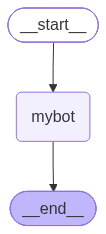

In [90]:
# Render mermaid workflow diagram for chatbot graph
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [91]:
# Construct initial human message input
input = {"messages": [HumanMessage(content="Hi hello, how are you?")]}

In [92]:
# Invoke chatbot graph app with initial message
result = app.invoke(input)


MYBOT NODE
Current Messages: [HumanMessage(content='Hi hello, how are you?', additional_kwargs={}, response_metadata={}, id='af78cb9f-ae9f-42b3-82c4-44de3334d43d')]

Model Response: Hi there! I’m doing great—thanks for asking. How can I help you today?


### 2.4 LangGraph State Schema Comparison

```text
State Schema Options
├── TypedDict (Default - Explicit Python dictionary schema)
├── Dataclass (Object-oriented Python class schema)
├── Pydantic BaseModel (Strict validation & default value schema)
└── Built-in MessagesState (Pre-configured list of BaseMessage objects with add_messages reducer)
```

## 3. Custom State Tracking & Token Metadata Pipeline

Demonstrates how to design custom `State` schemas with optional fields (`NotRequired`) to pass structured metadata (e.g., input/output tokens, raw responses) between specialized nodes.

In [121]:
# example llm call to understand metadata
response =llm.invoke("hi hello how are you?")

In [122]:
# View response content
response.content

'Hello! I’m doing great—thanks for asking. How can I help you today?'

In [123]:
# View token usage metadata from response
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 56,
 'total_tokens': 133,
 'output_token_details': {'reasoning': 29}}

### 3.1 Custom State Schema with Token Tracking

In [107]:
# Define custom State schema with optional token metadata fields
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import AIMessage
class State(TypedDict):
    # User input
    question: str
    # Generated answer
    answer: NotRequired[str]
    # Complete model response
    response: NotRequired[AIMessage]
    # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

### 3.2 Decoupled LLM Node & Token Counter Node
- `llm_node`: Calls LLM and saves raw `AIMessage` to state.
- `token_counter`: Inspects `response.usage_metadata` and extracts token metrics without altering prompt generation logic.

In [108]:
# LLM node generating answer and storing AIMessage response
def llm_node(state: State):
    print("\n========================")
    print("LLM NODE")
    print("========================")
    
    response = llm.invoke(state["question"])
    print("\nGenerated Answer:\n", response.content)
    
    # IMPORTANT:
    # We are NOT counting tokens here.
    # We simply save the complete AIMessage
    # so the next node can inspect its token metadata.
    return { "answer": response.content, "response": response}

In [109]:
# Token counter node extracting usage metadata from AIMessage
def token_counter(state: State):
    print("\n========================")
    print("TOKEN COUNTER NODE")
    print("========================")
    response = state["response"]
    
    usage = response.usage_metadata or {}

    input_tokens = usage.get("input_tokens")
    output_tokens = usage.get("output_tokens")
    total_tokens = usage.get("total_tokens")

    print("Input Tokens:", input_tokens)
    print("Output Tokens:", output_tokens)
    print("Total Tokens:", total_tokens)

    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens}

### 3.3 Assembling & Executing Token Counter Pipeline

In [110]:
# Instantiate StateGraph with custom State
workflow = StateGraph(State)

In [111]:
# Register llm node
workflow.add_node("llm", llm_node)

In [112]:
# Register token_counter node
workflow.add_node("token_counter", token_counter)

In [113]:
# Connect START -> llm -> token_counter -> END edges
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "token_counter")
workflow.add_edge("token_counter", END)

In [114]:
# Compile token counter workflow graph
app = workflow.compile()

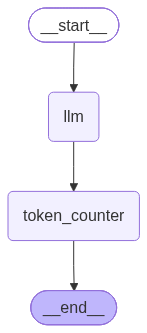

In [115]:
# Display token counter graph mermaid diagram
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [116]:
# Invoke graph with sample question
result = app.invoke({"question": "Tell me about Tata Group in detail."})


LLM NODE

Generated Answer:
 **Tata Group – A Comprehensive Overview**

| Item | Detail |
|------|--------|
| **Founded** | 1868 (as Tata Iron and Steel Company) |
| **Founder** | Jamsetji Tata |
| **Headquarters** | Mumbai, India (Tata Sons Ltd. – the holding company) |
| **Core Values** | “We do the right thing” – ethical, responsible, and sustainable business |
| **Global Presence** | 100+ countries, 100,000+ employees, 10+ sectors |
| **Key Holding** | Tata Sons Ltd. (66 % owned by Tata Trusts) |
| **Chairman (2026)** | Natarajan Chandrasekaran |
| **Revenue (FY 2025)** | ~₹3.6 trn (~US$47 bn) |
| **Market Cap (Tata Sons)** | ~US$35 bn (as of mid‑2026) |

---

## 1. Historical Milestones

| Year | Event |
|------|-------|
| **1868** | Tata Iron and Steel Company (TISCO) founded in Jamshedpur, the first steel plant in India. |
| **1912** | Tata Group starts its first overseas venture – Tata Oil Mills in the UK. |
| **1938** | Tata Motors (then Tata Engineering & Locomotive Co.) beg

In [117]:
# Inspect output state containing extracted token counts
result

{'question': 'Tell me about Tata Group in detail.',
 'answer': '**Tata Group – A Comprehensive Overview**\n\n| Item | Detail |\n|------|--------|\n| **Founded** | 1868 (as Tata Iron and Steel Company) |\n| **Founder** | Jamsetji Tata |\n| **Headquarters** | Mumbai, India (Tata Sons Ltd. – the holding company) |\n| **Core Values** | “We do the right thing” – ethical, responsible, and sustainable business |\n| **Global Presence** | 100+ countries, 100,000+ employees, 10+ sectors |\n| **Key Holding** | Tata Sons Ltd. (66\u202f% owned by Tata Trusts) |\n| **Chairman (2026)** | Natarajan\u202fChandrasekaran |\n| **Revenue (FY\u202f2025)** | ~₹3.6\u202ftrn (~US$47\u202fbn) |\n| **Market Cap (Tata Sons)** | ~US$35\u202fbn (as of mid‑2026) |\n\n---\n\n## 1. Historical Milestones\n\n| Year | Event |\n|------|-------|\n| **1868** | Tata Iron and Steel Company (TISCO) founded in Jamshedpur, the first steel plant in India. |\n| **1912** | Tata Group starts its first overseas venture – Tata Oil Mil

## 4. Enterprise Agentic RAG with Supervisor Routing & Quality Validation Loop

This section constructs a production-grade autonomous agentic pipeline featuring:
- **Supervisor Router**: Analyzes user intent and selects the optimal path (`RAG`, `LLM`, or `WEB`).
- **Specialized Execution Nodes**: RAG (internal Chroma vector store), WEB (real-time Tavily search), LLM (general knowledge).
- **Quality Control Validator**: Evaluates answers for relevance, grounding, and hallucination.
- **Self-Correction Retry Loop**: Automatically re-routes failed queries with feedback up to `MAX_ATTEMPTS`.

### 4.1 System Architecture & Data Flow

```text
User Question
     │
     ▼
[Supervisor Node] ──► Selects Route (RAG / LLM / WEB)
     │
     ├───────────────┼───────────────┐
     ▼               ▼               ▼
 [RAG Node]     [LLM Node]      [WEB Node]
     │               │               │
     └───────────────┼───────────────┘
                     │
                     ▼
            [Validator Node] (Evaluates relevance, grounding, & score)
                     │
         ┌───────────┴───────────┐
         ▼                       ▼
  Score >= 7 (Pass)       Score < 7 (Fail & Attempts < 3)
         │                       │
         ▼                       ▼
   [Final Node]          Re-route to [Supervisor] with Feedback
         │                       │
         ▼                       ▼
       (END)             Attempts >= 3 ──► [Failed Node] ──► (END)
```

<div style="width: 20%;">

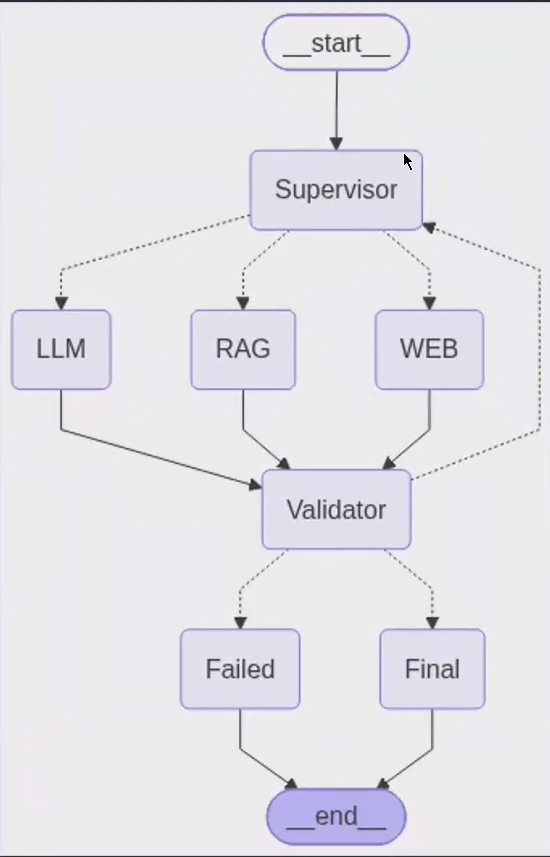

</div>

### 4.2 Initializing Vector Store & Tavily Web Search Tools

In [1]:
# Import dependencies for Agentic RAG pipeline
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
# LangGraph
from langgraph.graph import (
    StateGraph,
    START,
    END,
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_12456\2074771821.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (


In [2]:
# Initialize ChatGroq supervisor/generator LLM model
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.13'}}, output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002761C592350>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002761C801150>, model_name='openai/gpt-oss-20b', temperature=0.6, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
# Initialize HuggingFace BGE embeddings model
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [4]:
# Test embedding dimension length
embedding_vector = embeddings.embed_query("Hello")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [5]:
# Define data path for internal US economy text documents
Data_Path = r"D:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\06_Agentic_AI\data"

In [6]:
# Configure DirectoryLoader for text files
loader = DirectoryLoader(
    Data_Path,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={
        "encoding": "utf-8"
    }
)

In [7]:
# Load raw text documents
docs = loader.load()
print("Total documents loaded:", len(docs))

Total documents loaded: 1


In [8]:
# Inspect loaded documents
docs

[Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla. Innovation, research, advanced infrastructure, and access to capital support long-term economic growth. The U.S. dollar is widely used in international trade and is also a major global reserve currency. The country exports aircraft, software, pharmaceuticals, industrial equipment, agricultural goods, and financial services. Major economic challenges include inflation, public debt, income inequality, housing costs, and competition from other global economies. The Federal Reserve manages monetary policy by adjusting interest rate

In [9]:
# Initialize RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

In [10]:
# Chunk raw documents into overlapping text splits
new_docs = text_splitter.split_documents(docs)
print("Total chunks:", len(new_docs))

Total chunks: 13


In [11]:
# Inspect document chunks
new_docs

[Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing,'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla.'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06

In [12]:
# Initialize persistent Chroma vector store
vector_store = Chroma(
    collection_name="usa_economy",
    embedding_function=embeddings
)

In [13]:
# Populate Chroma vector store with document chunks
vector_store.add_documents(
    documents=new_docs
)

['5ccacc98-ebbe-4a4a-a297-9362875286ac',
 '55541333-53be-40c7-b95f-66ef3896f226',
 '6025d24f-7539-4277-bd58-74bf478d48db',
 '14aff40a-66b2-417d-9d18-c01ad0f29cdc',
 'e82b798b-8e2f-48dd-8a93-8f1febf56bbc',
 '5d72b71c-a6cb-41aa-a9a1-f2a55b8ce15a',
 '053905bf-707f-4921-b0be-c990312114d3',
 '707b6f64-2261-446e-a66b-646d63154880',
 'c6bf7071-ce74-494c-b888-dfcba761e4d7',
 '4844b736-adb7-4b01-b67f-d731c4d7ee28',
 '24aa292b-7b83-47a2-bcbe-a9f126cdfd0b',
 'f25a6ad1-0c11-4a9e-9a8c-43dae3566ad8',
 'ed1e1d38-682d-4a71-9670-c2e5f5d180f0']

In [14]:
# Create retriever interface from vector store (k=3)
retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [15]:
# Test retriever invocation on sample query
test_documents = retriever.invoke("What is GDP of USA?")

for document in test_documents:
    print(document.page_content)
    print("-" * 50)

The United States economy is one of the largest and most diversified economies in the world. It is
--------------------------------------------------
economies. The Federal Reserve manages monetary policy by adjusting interest rates and controlling
--------------------------------------------------
goods, and financial services. Major economic challenges include inflation, public debt, income
--------------------------------------------------


In [16]:
# Initialize TavilySearch real-time web search tool
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    topic="general"
)

In [17]:
# Test Tavily search tool invocation
result = web_search.invoke({"query": "What is the latest AI news?"})

In [18]:
# Inspect Tavily web search results
print(result)

{'query': 'What is the latest AI news?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026', 'title': 'The latest AI news we announced in July 2026 - Google Blog', 'content': '# The latest AI news we announced in July 2026\n\nAug 04, 2026\n\n|\n9 min read\n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\nHere’s a recap of some of our biggest AI updates from July, including three new Gemini models for building AI agents at scale and Gemini Robotics ER 2 to help robots reason, collaborate, and solve real-world tasks.\n\n  \n\nNews from Google Team\n\n Share \n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\n  \n\nImage 2: July AI recap header\n\n00:00\n\nAudio 1\n\n Listen to article \n\n minutes\n\nThis content is generated by Google AI. Generative AI is experimental\n\nVoice Umbriel Speed 1X\n\nVoice Umbriel Gacrux\n\nSpeed 0.75X 1X 1.5X 2X\n\n Rea

### 4.3 Structured Output Schemas (Pydantic Models)
Define Pydantic models for structured LLM JSON outputs: `RouteDecision` for routing and `ValidationResult` for quality scoring.

In [19]:
# Define RouteDecision Pydantic schema for supervisor decisions
class RouteDecision(BaseModel):
    route: Literal["RAG","LLM","WEB"] = Field(description="Node that should handle the user query")
    reasoning: str = Field(description="Reason for selecting this node")

#### Pydantic Structured Output Schema (`RouteDecision.model_json_schema()`)

When enforcing structured JSON output via `llm.with_structured_output(schema=RouteDecision.model_json_schema(), method="json_schema")`, the model generates responses adhering to the following schema:

```json
{
  "title": "RouteDecision",
  "type": "object",
  "properties": {
    "route": {
      "title": "Route",
      "type": "string",
      "enum": ["RAG", "LLM", "WEB"],
      "description": "Node that should handle the user query"
    },
    "reasoning": {
      "title": "Reasoning",
      "type": "string",
      "description": "Reason for selecting this node"
    }
  },
  "required": ["route", "reasoning"]
}
```


#### Pydantic Structured Output Schema (`RouteDecision.model_json_schema()`)

When enforcing structured JSON output via `llm.with_structured_output(schema=RouteDecision.model_json_schema(), method="json_schema")`, the model generates responses adhering to the following schema:

```json
{
  "title": "RouteDecision",
  "type": "object",
  "properties": {
    "route": {
      "title": "Route",
      "type": "string",
      "enum": ["RAG", "LLM", "WEB"],
      "description": "Node that should handle the user query"
    },
    "reasoning": {
      "title": "Reasoning",
      "type": "string",
      "description": "Reason for selecting this node"
    }
  },
  "required": ["route", "reasoning"]
}
```


In [25]:
# Test supervisor structured routing model
supervisor_model.invoke("can you tell me the USA current GDP?")

{'route': 'WEB',
 'reasoning': "User requests current USA GDP, which requires up-to-date external data not available in the model's knowledge base."}

In [26]:
# validation schema
class ValidationResult(BaseModel):
    passed: bool = Field(description="True if the generated answer passes validation")
    score: int = Field(ge=0,le=10,description="Quality score from 0 to 10")
    feedback: str = Field(description="Reason for validation result")

In [27]:
# Bind structured output schema to validator model
validator_model = llm.with_structured_output(schema=ValidationResult.model_json_schema(),method="json_schema")

### 4.4 Agent State Definition
Define `AgentState` TypedDict tracking user question, route decisions, reasoning, context, draft answers, validation scores, feedback, attempt counters, and final output.

In [28]:
# Define complete AgentState schema for multi-agent graph
class AgentState(TypedDict, total=False):
    # Original user query
    question: str
    # Supervisor decision
    route: str
    # Supervisor reasoning
    route_reasoning: str
    # Context from RAG / Web
    context: str
    # Answer generated by RAG / LLM / Web
    draft_answer: str
    # Validation result
    validation_passed: bool
    
    validation_score: int
    
    validation_feedback: str

    # Retry information
    attempts: int

    # Keep track of previously used routes
    used_routes: list[str]

    # Answer shown to user only after validation
    final_answer: str

### 4.5 Supervisor Router Node
Prompts the LLM to inspect user intent, previous route attempts, and prior validation feedback to decide the next action.

In [29]:
# Implement supervisor_node for intelligent query routing
def supervisor_node(state: AgentState):

    print("\n==============================")
    print("SUPERVISOR NODE")
    print("==============================")

    question = state["question"]

    previous_feedback = state.get("validation_feedback","")

    used_routes = state.get("used_routes", [])

    attempts = state.get("attempts", 0)

    supervisor_prompt = f"""
You are the supervisor of an AI system.

Your responsibility is to decide which node should answer
the user's question.

You have three possible nodes:

1. RAG

Use RAG when:
- the question is related to the USA economy
- GDP of USA
- industrial growth of USA
- US economic sectors
- US debt
- US economic strengths
- USA economic information contained in our internal documents

The RAG knowledge base mainly contains information
about the United States economy.


2. WEB

Use WEB when:
- the user asks for current information
- today
- latest
- realtime
- recent news
- current stock price
- current weather
- latest economic information
- information that may have changed recently
- internal RAG documents may be outdated


3. LLM

Use LLM when:
- the question is general knowledge
- casual conversation
- greeting
- conceptual question
- question unrelated to the USA knowledge base
- information does not require current internet data


User Question:
{question}


Routes already attempted:

{used_routes}


Previous validation feedback:

{previous_feedback}


Important:

If a previous answer failed validation,
use the validation feedback to decide whether another
information source should be selected.

Return the best route.
"""


    decision = supervisor_model.invoke(
        supervisor_prompt
    )


    route = decision["route"]

    reasoning = decision["reasoning"]


    print("Selected Route:", route)

    print("Reasoning:", reasoning)


    updated_routes = (used_routes + [route])


    return {
        "route": route,

        "route_reasoning": reasoning,

        "attempts": attempts + 1,

        "used_routes": updated_routes,

        # Clear previous attempt
        "context": "",

        "draft_answer": "",
    }

### 4.6 Execution Nodes (RAG, General LLM, Web Search)
- `rag_node`: Queries Chroma vector store for US economic data.
- `llm_node`: Handles general conversational questions.
- `web_node`: Fetches real-time internet search context via Tavily.

In [30]:
# Define router conditional edge function
def router(state: AgentState):

    print("\n-> ROUTER ->")
    route = state["route"]
    print("Routing to:", route)
    
    return route

In [31]:
# Helper function to format retrieved Document objects into string context
def format_docs(documents):

    return "\n\n".join(
        document.page_content
        for document in documents
    )

In [33]:
# Implement rag_node for internal knowledge retrieval
def rag_node(state: AgentState):

    print("\n==============================")
    print("RAG NODE")
    print("==============================")

    question = state["question"]

    # -----------------------------------
    # Retrieve documents
    # -----------------------------------

    retrieved_docs = retriever.invoke(
        question
    )

    context = format_docs(
        retrieved_docs
    )

    print("Retrieved Documents:", len(retrieved_docs))

    # -----------------------------------
    # Generate answer
    # -----------------------------------

    rag_prompt = f"""
You are a question-answering assistant.

Answer the user's question using ONLY the supplied
retrieved context.

If the context does not contain enough information,
clearly say that the available internal knowledge
is insufficient.

Do not invent facts.

User Question:

{question}


Retrieved Context:

{context}


Generate a clear and concise answer.
"""

    response = llm.invoke(
        rag_prompt
    )

    answer = response.content

    print("RAG Answer:", answer)

    return {
        "context": context,
        "draft_answer": answer,
    }

In [34]:
# Implement llm_node for general knowledge questions
def llm_node(state: AgentState):

    print("\n==============================")
    print("LLM NODE")
    print("==============================")

    question = state["question"]

    prompt = f"""
Answer the following question using your general
knowledge.

Give a clear, accurate and useful response.

If the question requires current or real-time information
that you cannot reliably know, explicitly mention that
real-time information should be checked.

Question:

{question}
"""

    response = llm.invoke(
        prompt
    )

    answer = response.content

    print("LLM Answer:", answer)

    return {
        "context": "",
        "draft_answer": answer,
    }

In [35]:
# Implement web_node for real-time Tavily search
def web_node(state: AgentState):

    print("\n==============================")
    print("WEB SEARCH NODE")
    print("==============================")

    question = state["question"]

    # -----------------------------------
    # Search realtime internet
    # -----------------------------------
    search_result = web_search.invoke({"query": question})

    # -----------------------------------
    # Convert returned data to text
    # -----------------------------------
    if isinstance(search_result,dict):

        results = search_result.get(
            "results",
            []
        )


        if results:

            web_context_parts = []

            for result in results:

                title = result.get("title", "")

                url = result.get("url", "")

                content = result.get("content", "")

                web_context_parts.append(

                    f"""
Title:
{title}

URL:
{url}

Content:
{content}
"""

                )


            web_context = "\n\n".join(
                web_context_parts
            )


        else:

            web_context = json.dumps(

                search_result,

                indent=2,

                ensure_ascii=False,

                default=str

            )


    else:
        web_context = str(search_result)

    print("Web search completed.")

    # -----------------------------------
    # Generate answer using web context
    # -----------------------------------

    web_prompt = f"""
You are answering a user question using current
web-search results.

Use the web information below to answer the question.

Do not fabricate facts.

When useful, mention the source names or URLs
available in the search result.

User Question:

{question}


Web Search Results:

{web_context}


Generate the best answer based on the current
web information.
"""
    response = llm.invoke(web_prompt)

    answer = response.content

    print("WEB Answer:", answer)

    return {
        "context": web_context,
        "draft_answer": answer,
    }


### 4.7 Quality Control Validator Node
Evaluates generated draft answers against 5 quality dimensions (Relevance, Correctness, Completeness, Hallucination, Source Grounding) and assigns a score from 0-10.

In [36]:
# Implement validator_node for multi-dimensional quality assessment
def validator_node(state: AgentState):

    print("\n==============================")
    print("VALIDATOR NODE")
    print("==============================")

    question = state["question"]

    route = state["route"]

    answer = state["draft_answer"]

    context = state.get(
        "context",
        ""
    )


    validation_prompt = f"""
You are the quality-control validator of an AI system.

Evaluate whether the generated answer is acceptable.


USER QUESTION:

{question}


NODE USED:

{route}


SOURCE CONTEXT:

{context}


GENERATED ANSWER:

{answer}


Validate the answer using these criteria:


1. RELEVANCE

Does the answer directly answer the user's question?


2. CORRECTNESS

Does the answer appear logically and factually correct
based on the available evidence?


3. COMPLETENESS

Does it provide enough information to answer the question?


4. HALLUCINATION

Does the answer make unsupported claims?


5. SOURCE GROUNDING

If NODE USED = RAG:

The answer must be supported by the retrieved context.


If NODE USED = WEB:

The answer must be supported by the web search context.


If NODE USED = LLM:

The answer should be suitable for general stable knowledge
and must not pretend to know unavailable real-time facts.


SCORING:

0-4  = poor
5-6  = needs improvement
7    = acceptable but weak
8-10 = good


PASS only if the score is 7 or higher and there is no
major factual or grounding problem.


Return:

passed
score
feedback
"""


    result = validator_model.invoke(
        validation_prompt
    )

    passed = result["passed"]

    score = result["score"]

    feedback = result["feedback"]

    print("Validation Passed:",passed)
    print("Score:",score)
    print("Feedback:",feedback)

    return {
        "validation_passed": passed,
        "validation_score": score,
        "validation_feedback": feedback,
    }

### 4.8 Conditional Routing Logic & Retry Policy
Defines `validation_router` function to route state based on validation score and attempt count.

In [37]:
# Set maximum retry limit
MAX_ATTEMPTS = 3

In [38]:
# Define validation_router conditional edge function
def validation_router(state: AgentState):

    print("\n-> VALIDATION ROUTER ->")
    # -----------------------------------
    # Validation passed
    # -----------------------------------
    if state["validation_passed"]:
        print("Validation PASSED")
        return "Final"


    # -----------------------------------
    # Too many attempts
    # -----------------------------------
    if state.get("attempts",0) >= MAX_ATTEMPTS:
        print("Maximum attempts reached")
        return "Failed"

    # -----------------------------------
    # Validation failed -> supervisor
    # -----------------------------------
    print("Validation FAILED")
    print("Returning to Supervisor...")
    return "Supervisor"

In [39]:
# Implement final_node for successful outputs
def final_node(state: AgentState):

    print("\n==============================")
    print("FINAL ANSWER NODE")
    print("==============================")

    answer = state["draft_answer"]

    return {
        "final_answer": answer
    }

In [40]:
# Implement failed_node for retry-exhausted queries
def failed_node(state: AgentState):

    print("\n==============================")
    print("VALIDATION FAILED AFTER RETRIES")
    print("==============================")

    message = (
        "The system could not generate a sufficiently "
        "validated answer after multiple attempts."
    )

    return {
        "final_answer": message
    }

### 4.9 Assembling, Compiling, & Visualizing the Agentic Graph

In [43]:
# Instantiate StateGraph with AgentState
workflow = StateGraph(AgentState)

In [44]:
# Register all nodes in the Agentic Graph
workflow.add_node("Supervisor",supervisor_node)
workflow.add_node("RAG",rag_node)
workflow.add_node("LLM",llm_node)
workflow.add_node("WEB",web_node)
workflow.add_node("Validator",validator_node)
workflow.add_node("Final",final_node)
workflow.add_node("Failed",failed_node)

In [45]:
# Connect workflow edges and conditional routing branches
workflow.add_edge(START,"Supervisor")
workflow.add_conditional_edges("Supervisor",
                            router,
    {
        "RAG": "RAG",

        "LLM": "LLM",

        "WEB": "WEB",

    }

)
workflow.add_edge("RAG","Validator")
workflow.add_edge("LLM","Validator")
workflow.add_edge("WEB","Validator")
workflow.add_conditional_edges(
    "Validator",
    validation_router,
    {
        "Final": "Final",
        "Supervisor": "Supervisor",
        "Failed": "Failed",

    }

)
workflow.add_edge("Final",END)
workflow.add_edge("Failed",END)

In [46]:
# Compile complete Agentic Graph workflow app
app = workflow.compile()
print("\nGraph compiled successfully.")


Graph compiled successfully.


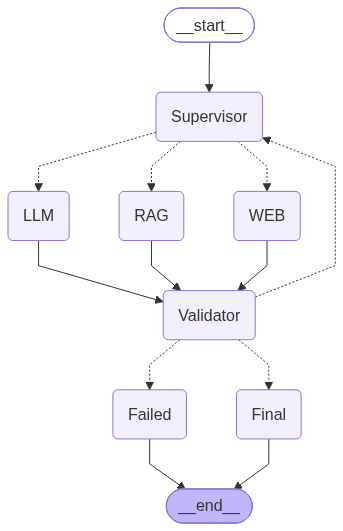

In [47]:
# Display complete Agentic Graph mermaid diagram
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))

### 4.10 Comprehensive Test Suite & Execution Evaluation
Test the agentic system across different query categories: general greetings, internal US economy RAG data, real-time web news, and edge cases.

In [48]:
# Helper function to run end-to-end queries with state logging
def ask_agent(question: str):

    initial_state = {
        "question": question,
        "attempts": 0,
        "used_routes": [],
        "validation_feedback": "",
        "validation_passed": False,
        "validation_score": 0,
        "context": "",
        "draft_answer": "",
        "final_answer": "",
    }

    result = app.invoke(
        initial_state,
        {
            "recursion_limit": 30
        }
    )

    print("\n\n================================")
    print("FINAL RESULT")
    print("================================")

    print("Question:")
    print(result["question"])

    print("\nFinal Route:")
    print(result.get("route"))

    print("\nRoutes Tried:")
    print(result.get("used_routes"))

    print("\nValidation Score:")
    print(result.get("validation_score"))

    print("\nValidation Feedback:")
    print(result.get("validation_feedback"))

    print("\nFinal Answer:")
    print(result["final_answer"])

    return result

In [49]:
# Test Case 1: General greeting query
result = ask_agent("hi can you help me?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user’s greeting and request for help is a general conversational inquiry, not specific to USA economic data or requiring current real‑time information. Thus the LLM node is appropriate.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Sure thing! What do you need help with? Whether it’s a quick question, a deeper explanation, or something else, just let me know and I’ll do my best to assist you. If you’re looking for up‑to‑date or time‑sensitive information (like current events, stock prices, weather, etc.), it’s a good idea to double‑check a reliable source since I can’t browse the web in real time.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer is relevant, accurate, and appropriately cautious about real‑time information. It invites clarification, which is suitable for the vague user query. No hallucinations or grounding issues are present.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FIN

In [50]:
# Test Case 2: Real-time query requiring web search
result = ask_agent("hcan you tell me the current GDP of china?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: User requests the current GDP of China, which is recent economic data not covered by the USA-focused RAG knowledge base. The request requires up-to-date information, so the WEB node is appropriate.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **China’s current Gross Domestic Product (GDP)**  

| Year (latest estimate) | Nominal GDP (current U.S. dollars) | Source |
|------------------------|-------------------------------------|--------|
| 2026 (IMF projection) | **$20.85 trillion** | Worldometer – “China GDP (2026)” (IMF) |
| 2025 (latest reported figure) | **$19.50 trillion** (≈ 19 498 billion USD) | Trading Economics – “China GDP” (World Bank data) |

**Key points**

* The IMF’s 2026 estimate (Worldometer) is the most recent projection and places China’s GDP at about **$20.85 trillion** in 2026.  
* The Trading Economics data, based on World Bank figures, reports China’s GDP for 2025 at **$19.50 tril

In [51]:
# Test Case 3: Internal knowledge query (USA economy)
result = ask_agent("What are the major economic challenges of the USA?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The question asks about major economic challenges of the USA, which is directly related to the USA economy and fits the RAG node's domain.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The major economic challenges of the United States, as noted in the supplied context, are:

- Inflation  
- Public debt  
- Income inequality  
- Housing costs  
- Competition from other global economies

VALIDATOR NODE
Validation Passed: True
Score: 8
Feedback: The answer directly addresses the question, accurately reflects the challenges listed in the provided context, and contains no unsupported claims. It is concise and well-grounded in the retrieved RAG context.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
What are the major economic challenges of the USA?

Final Route:
RAG

Routes Tried:
['RAG']

Validation Score:
8

Validation Feedback:
The answer directly addresses the question, 

In [52]:
# Test Case 4: US economic future growth document query
result = ask_agent("What does the document say about future growth of the U.S. economy?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The user is asking about the content of a document concerning future growth of the U.S. economy, which falls under the RAG knowledge base that covers U.S. economic information. The question does not request current or real‑time data, so the WEB node is not needed. Therefore the RAG node is the appropriate choice.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The supplied context does not contain a clear statement about the future growth of the U.S. economy. It mentions that capital support can help sustain long‑term growth, but it does not provide specific projections or details on future economic expansion.

VALIDATOR NODE
Validation Passed: True
Score: 8
Feedback: The answer appropriately addresses the user’s question by noting the lack of a clear statement on future growth in the provided context while correctly referencing the mention of capital support for long‑term growth. It is grounded in the source ma

In [53]:
# Test Case 5: Real-time news query
result = ask_agent("can you give me current update of the usa and iran war?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: User requests current update on USA and Iran war, requiring recent news and real-time information, which is best served by the WEB node.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **Current status of the U.S.–Iran conflict (as of early August 2026)**  

| What’s happening | Key facts | Source |
|------------------|-----------|--------|
| **War has resumed** | The U.S. and Iran are in an active conflict that began in February 2026 after the U.S. and Israel killed Iranian Supreme Leader Ali Khamenei and struck Iranian nuclear and military facilities.  The fighting has escalated to nightly attacks by Iranian‑backed forces on U.S. and coalition targets in Iraq, Syria, Yemen, and Lebanon, with the U.S. conducting retaliatory airstrikes. | Institute for the Study of War (ISW) “Iran Update Special Report, August 7 2026” |
| **U.S. operational posture** | The U.S. has paused large‑scale strikes for a short pe

In [56]:
# Test Case 6: Casual conversational query with name
result = ask_agent("hi my name is areeb how you are doing?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user is greeting and asking how I am doing, which is a general conversational question. It does not require current data or specific knowledge about the USA economy. Therefore the LLM node is the appropriate choice.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Hi Areeb! I’m doing well—thanks for asking. How can I help you today?

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer is relevant, correct, and complete for the user’s greeting. It does not contain unsupported claims and is appropriate for an LLM-generated response. No major issues identified.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
hi my name is areeb how you are doing?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The answer is relevant, correct, and complete for the user’s greeting. It does not contain unsupported claims and is appropriate for an LLM-generated res